# Exploratory Data Analysis

This notebook explores transaction patterns in the PaySim dataset and compares fraudulent and non-fraudulent transactions using statistical summaries and visualisations.

In [1]:
import pandas as pd

file_path = "../data/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

Dataset loaded successfully
Dataset shape: (6362620, 11)


## Transaction Type Distribution

This section examines the number and percentage of transactions for each transaction type.

In [4]:
transaction_type_counts = df["type"].value_counts()

transaction_type_percentages = (
    df["type"].value_counts(normalize=True) * 100
)

transaction_type_summary = pd.DataFrame({
    "Transaction Count": transaction_type_counts,
    "Percentage": transaction_type_percentages.round(2)
})

print(transaction_type_summary)

          Transaction Count  Percentage
type                                   
CASH_OUT            2237500       35.17
PAYMENT             2151495       33.81
CASH_IN             1399284       21.99
TRANSFER             532909        8.38
DEBIT                 41432        0.65


### Transaction Type Distribution Chart

This chart shows the total number of transactions for each transaction type.

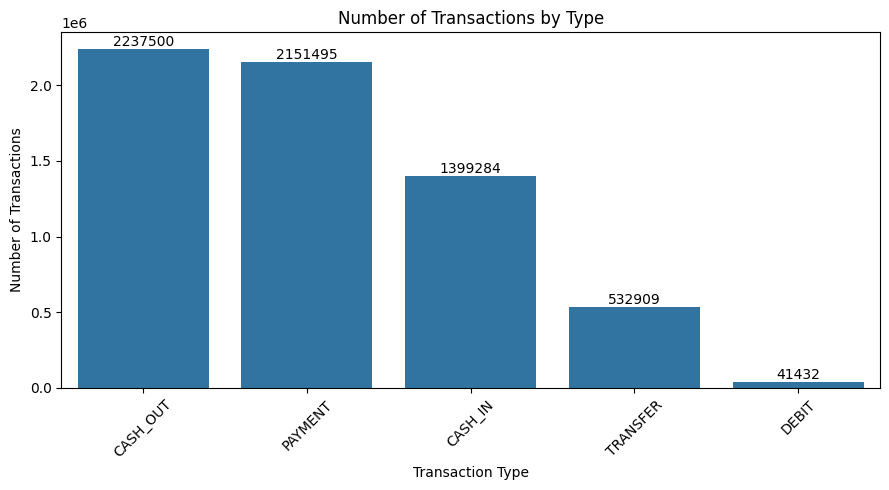

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=transaction_type_counts.index,
    y=transaction_type_counts.values
)

plt.title("Number of Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Fraud Analysis by Transaction Type

This section compares the total transactions, fraud transactions, and fraud rate for each transaction type.

In [13]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
    .agg(["count", "sum"])
    .reset_index()
)

fraud_by_type.columns = [
    "Transaction Type",
    "Total Transactions",
    "Fraud Transactions"
]

fraud_by_type["Fraud Rate (%)"] = (
    fraud_by_type["Fraud Transactions"]
    / fraud_by_type["Total Transactions"]
    * 100
).round(4)

fraud_by_type = fraud_by_type.sort_values(
    by="Fraud Transactions",
    ascending=False
)

fraud_by_type

,Transaction Type,Total Transactions,Fraud Transactions,Fraud Rate (%)
1,CASH_OUT,2237500,4116,0.1840
4,TRANSFER,532909,4097,0.7688
0,CASH_IN,1399284,0,0.0000
2,DEBIT,41432,0,0.0000
3,PAYMENT,2151495,0,0.0000


### Fraud Transactions by Type

This chart compares the number of fraudulent transactions across transaction types that contain fraud.

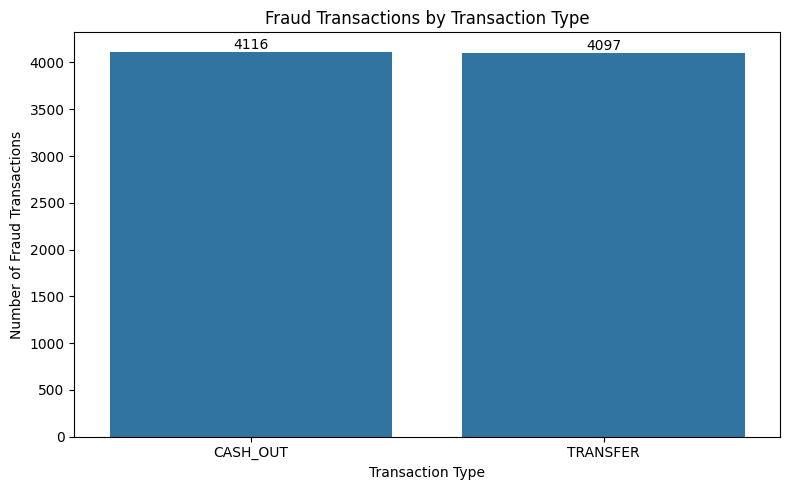

In [14]:
fraud_only = fraud_by_type[
    fraud_by_type["Fraud Transactions"] > 0
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=fraud_only,
    x="Transaction Type",
    y="Fraud Transactions"
)

plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

### Fraud Rate by Transaction Type

This chart compares the percentage of transactions identified as fraud within each transaction type that contains fraud.

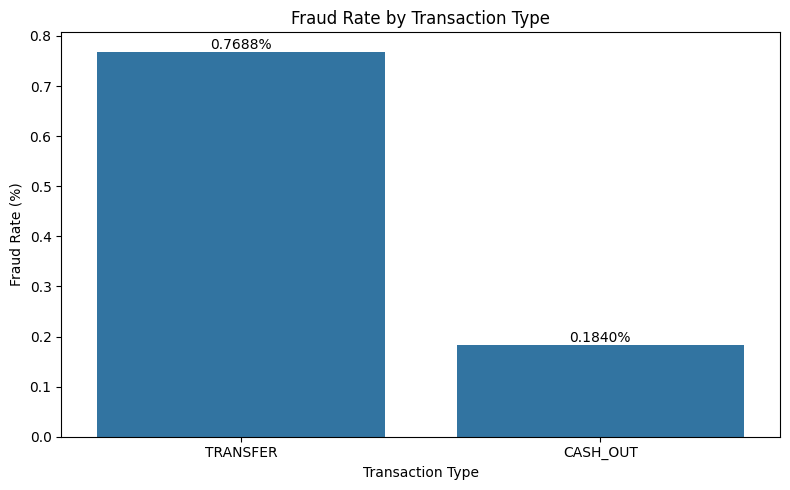

In [15]:
fraud_rate_plot = fraud_only.sort_values(
    by="Fraud Rate (%)",
    ascending=False
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=fraud_rate_plot,
    x="Transaction Type",
    y="Fraud Rate (%)"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f%%")

plt.tight_layout()
plt.show()

### Fraud by Transaction Type — Key Insight

Fraud occurs only in `CASH_OUT` and `TRANSFER` transactions in this dataset.

`CASH_OUT` contains 4,116 fraud cases, while `TRANSFER` contains 4,097 fraud cases. Although the fraud counts are almost equal, the fraud rate is much higher for `TRANSFER`.

- `TRANSFER` fraud rate: 0.7688%
- `CASH_OUT` fraud rate: 0.1840%

This indicates that `TRANSFER` transactions have a higher relative fraud risk. Therefore, transaction type may be an important feature when building the fraud-detection model.

`CASH_IN`, `DEBIT`, and `PAYMENT` contain no labelled fraud transactions in this dataset.

## Transaction Amount Analysis

This section compares transaction amounts between fraudulent and non-fraudulent transactions.

In [16]:
amount_summary = (
    df.groupby("isFraud")["amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

amount_summary.index = ["Non-Fraud", "Fraud"]

amount_summary

,count,mean,median,min,max
Non-Fraud,6354407,178197.04,74684.72,0.01,92445516.64
Fraud,8213,1467967.30,441423.44,0.00,10000000.00


### Average and Median Transaction Amount

This chart compares the mean and median transaction amounts for fraudulent and non-fraudulent transactions.

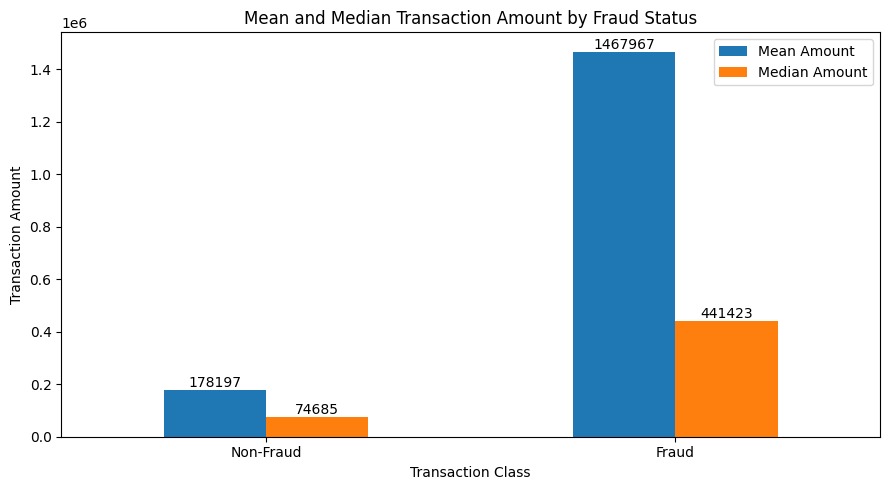

In [17]:
amount_comparison = amount_summary[["mean", "median"]]

ax = amount_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Mean and Median Transaction Amount by Fraud Status")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=0)
plt.legend(["Mean Amount", "Median Amount"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

### Transaction Amount — Key Insight

Fraudulent transactions generally involve much larger amounts than non-fraudulent transactions.

- Non-fraud mean amount: 178,197
- Fraud mean amount: 1,467,967
- Non-fraud median amount: 74,685
- Fraud median amount: 441,423

The average fraudulent transaction is approximately 8.2 times larger than the average non-fraudulent transaction. The median fraudulent transaction is approximately 5.9 times larger.

For both classes, the mean is higher than the median. This indicates that transaction amounts are right-skewed, with some unusually large transactions increasing the average.

Transaction amount may therefore be an important feature for fraud detection. However, it should not be used alone because some legitimate transactions may also involve large amounts.

## Transaction Amount Percentiles

This section compares transaction amount percentiles for fraudulent and non-fraudulent transactions.

In [19]:
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

non_fraud_percentiles = df.loc[
    df["isFraud"] == 0,
    "amount"
].quantile(percentiles)

fraud_percentiles = df.loc[
    df["isFraud"] == 1,
    "amount"
].quantile(percentiles)

amount_percentiles = pd.DataFrame({
    "Non-Fraud": non_fraud_percentiles,
    "Fraud": fraud_percentiles
})

amount_percentiles.index = [
    "25%",
    "50%",
    "75%",
    "90%",
    "95%",
    "99%"
]

amount_percentiles.round(2)

,Non-Fraud,Fraud
25%,13368.40,127091.33
50%,74684.72,441423.44
75%,208364.76,1517771.48
90%,364373.44,4521723.51
95%,515610.42,8006429.04
99%,1586064.17,10000000.00


### Interactive Transaction Amount Percentiles

This interactive chart compares transaction amount percentiles for fraudulent and non-fraudulent transactions.

In [22]:
import plotly.express as px

percentile_plot = amount_percentiles.reset_index()

percentile_plot = percentile_plot.rename(
    columns={"index": "Percentile"}
)

fig = px.bar(
    percentile_plot,
    x="Percentile",
    y=["Non-Fraud", "Fraud"],
    barmode="group",
    title="Transaction Amount Percentiles by Fraud Status",
    labels={
        "value": "Transaction Amount",
        "variable": "Transaction Class"
    }
)

fig.update_layout(
    yaxis_tickformat=","
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [21]:
%pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 32.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
import plotly.express as px

percentile_plot = amount_percentiles.reset_index()

percentile_plot = percentile_plot.rename(
    columns={"index": "Percentile"}
)

fig = px.bar(
    percentile_plot,
    x="Percentile",
    y=["Non-Fraud", "Fraud"],
    barmode="group",
    title="Transaction Amount Percentiles by Fraud Status",
    labels={
        "value": "Transaction Amount",
        "variable": "Transaction Class"
    }
)

fig.update_layout(
    yaxis_tickformat=","
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [24]:
%pip install --upgrade nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [nbformat]6/7 [nbformat]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
fig.show(renderer="browser")

In [27]:
import plotly.io as pio

pio.renderers.default = "vscode"

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### Transaction Amount Percentile — Key Insight

Fraudulent transactions have substantially higher transaction amounts than non-fraudulent transactions across all examined percentiles.

The difference becomes larger in the upper percentiles. At the 90th, 95th, and 99th percentiles, fraudulent transaction amounts are several times higher than non-fraudulent transaction amounts.

This indicates that unusually large transaction amounts may be useful for identifying fraud. However, amount should be combined with other features because high-value legitimate transactions may also exist.

The interactive Plotly chart allows users to hover over each bar and inspect the exact transaction amount.

## Sender Balance After the Transaction

This section checks how often the sender's account balance becomes zero after fraudulent and non-fraudulent transactions.

In [28]:
non_fraud_zero_rate = (
    df.loc[df["isFraud"] == 0, "newbalanceOrig"] == 0
).mean() * 100

fraud_zero_rate = (
    df.loc[df["isFraud"] == 1, "newbalanceOrig"] == 0
).mean() * 100

zero_balance_summary = pd.DataFrame({
    "Transaction Class": ["Non-Fraud", "Fraud"],
    "Zero Balance Rate (%)": [
        non_fraud_zero_rate,
        fraud_zero_rate
    ]
})

zero_balance_summary["Zero Balance Rate (%)"] = (
    zero_balance_summary["Zero Balance Rate (%)"].round(2)
)

zero_balance_summary

,Transaction Class,Zero Balance Rate (%)
0,Non-Fraud,56.68
1,Fraud,98.05


### Sender Zero-Balance Rate by Fraud Status

This chart compares how often the sender's balance becomes zero after fraudulent and non-fraudulent transactions.

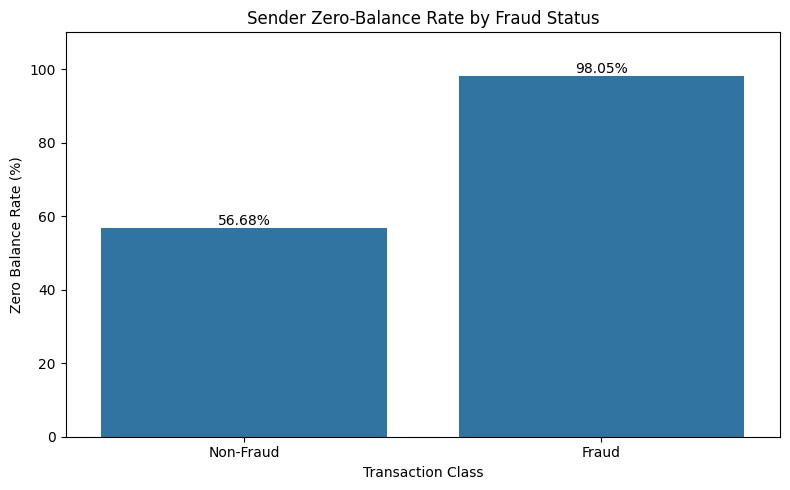

In [29]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=zero_balance_summary,
    x="Transaction Class",
    y="Zero Balance Rate (%)"
)

plt.title("Sender Zero-Balance Rate by Fraud Status")
plt.xlabel("Transaction Class")
plt.ylabel("Zero Balance Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.ylim(0, 110)

plt.tight_layout()
plt.show()

## Transaction Amount Compared with Sender Balance

This section checks how often the transaction amount is approximately equal to the sender's original account balance.

In [30]:
balance_difference = (
    df["oldbalanceOrg"] - df["amount"]
).abs()

amount_matches_balance = balance_difference < 0.01

non_fraud_match_rate = amount_matches_balance[
    df["isFraud"] == 0
].mean() * 100

fraud_match_rate = amount_matches_balance[
    df["isFraud"] == 1
].mean() * 100

balance_match_summary = pd.DataFrame({
    "Transaction Class": ["Non-Fraud", "Fraud"],
    "Amount Matches Original Balance (%)": [
        non_fraud_match_rate,
        fraud_match_rate
    ]
})

balance_match_summary[
    "Amount Matches Original Balance (%)"
] = balance_match_summary[
    "Amount Matches Original Balance (%)"
].round(2)

balance_match_summary

,Transaction Class,Amount Matches Original Balance (%)
0,Non-Fraud,0.00
1,Fraud,97.82


### Transaction Amount Matching Sender Balance

This chart compares how often the transaction amount approximately matches the sender's full original balance for fraudulent and non-fraudulent transactions.

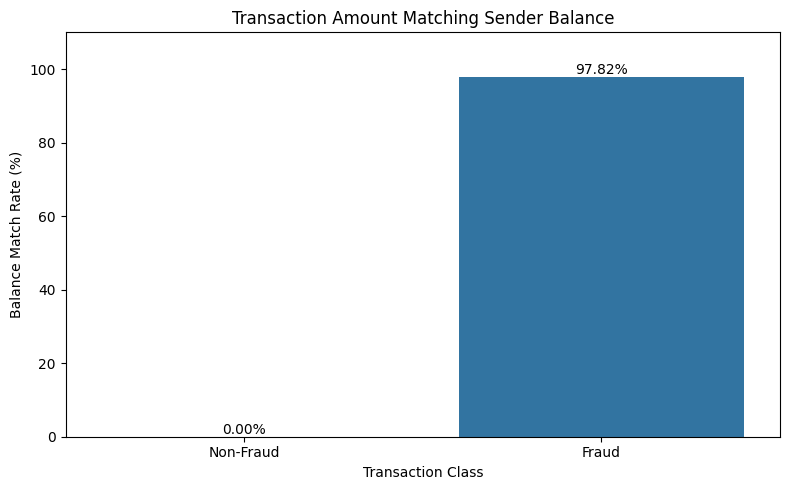

In [31]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=balance_match_summary,
    x="Transaction Class",
    y="Amount Matches Original Balance (%)"
)

plt.title("Transaction Amount Matching Sender Balance")
plt.xlabel("Transaction Class")
plt.ylabel("Balance Match Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.ylim(0, 110)

plt.tight_layout()
plt.show()

### Sender Balance Pattern — Key Insight

Fraudulent transactions show a strong account-draining pattern.

- 98.05% of fraud transactions leave the sender's balance at zero.
- 97.82% of fraud transactions transfer an amount approximately equal to the sender's original balance.
- These patterns are much less common in non-fraud transactions.

This suggests that fraudsters often attempt to move nearly all available money from the sender's account.

These findings may support useful engineered features such as:

- Whether the sender's new balance is zero
- Whether the transaction amount matches the sender's original balance
- The difference between the expected and actual sender balance

However, these features should be combined with transaction type, amount, time, and other balance information rather than used alone.